In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Visualization Style

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
df = pd.read_csv("dataset/Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [14]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

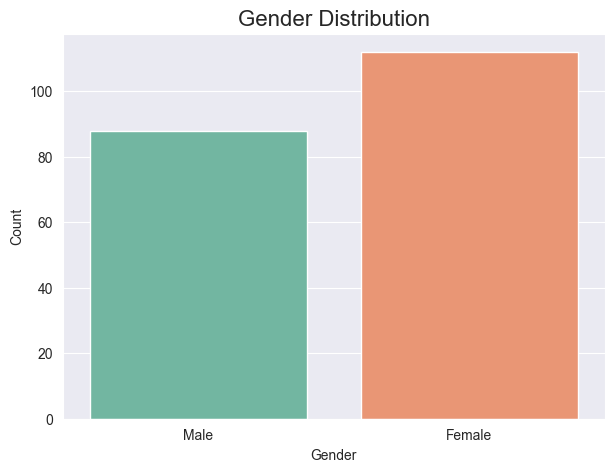

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Genre',
    data=df,
    palette='Set2'
)

plt.title("Gender Distribution", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

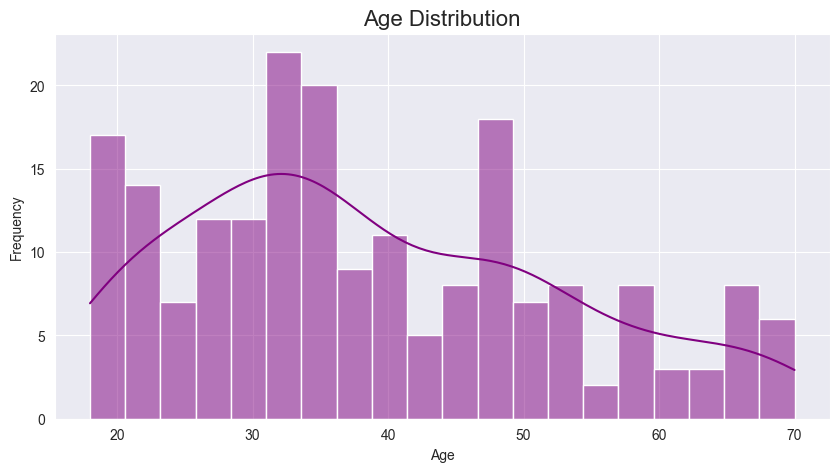

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title("Age Distribution", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

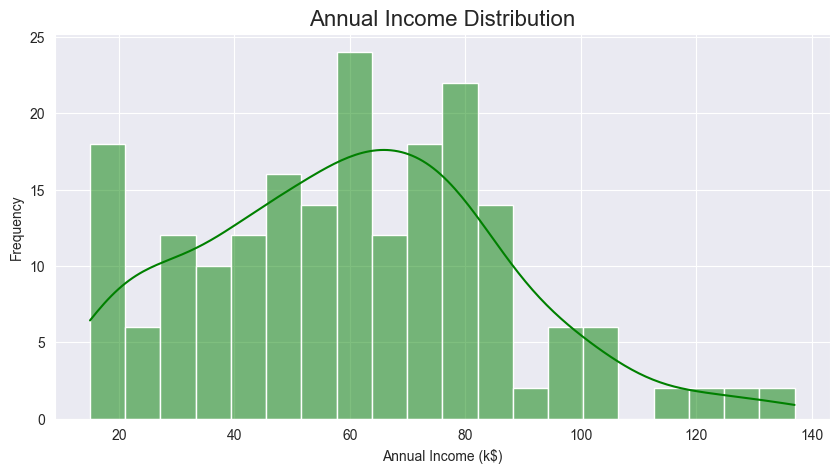

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Annual Income (k$)'],
    bins=20,
    kde=True,
    color='green'
)

plt.title("Annual Income Distribution", fontsize=16)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")

plt.show()

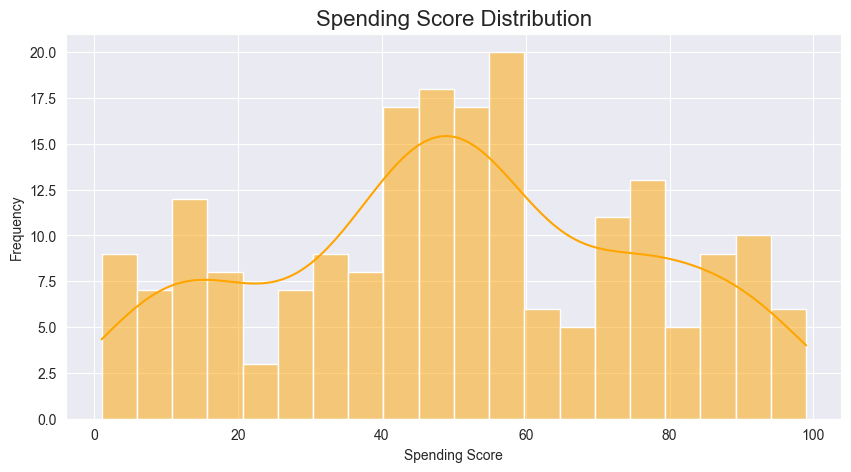

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=20,
    kde=True,
    color='orange'
)

plt.title("Spending Score Distribution", fontsize=16)
plt.xlabel("Spending Score")
plt.ylabel("Frequency")

plt.show()

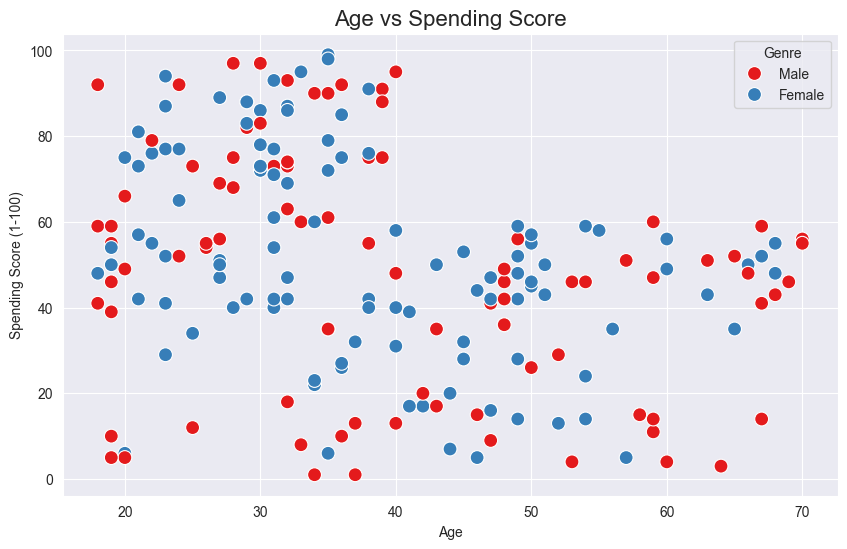

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    hue='Genre',
    data=df,
    palette='Set1',
    s=100
)

plt.title("Age vs Spending Score", fontsize=16)

plt.show()


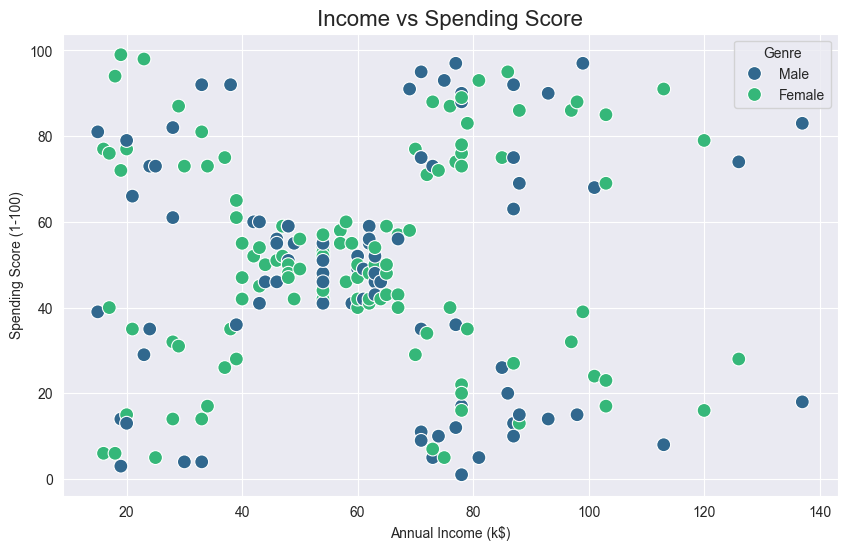

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Genre',
    data=df,
    palette='viridis',
    s=100
)

plt.title("Income vs Spending Score", fontsize=16)

plt.show()

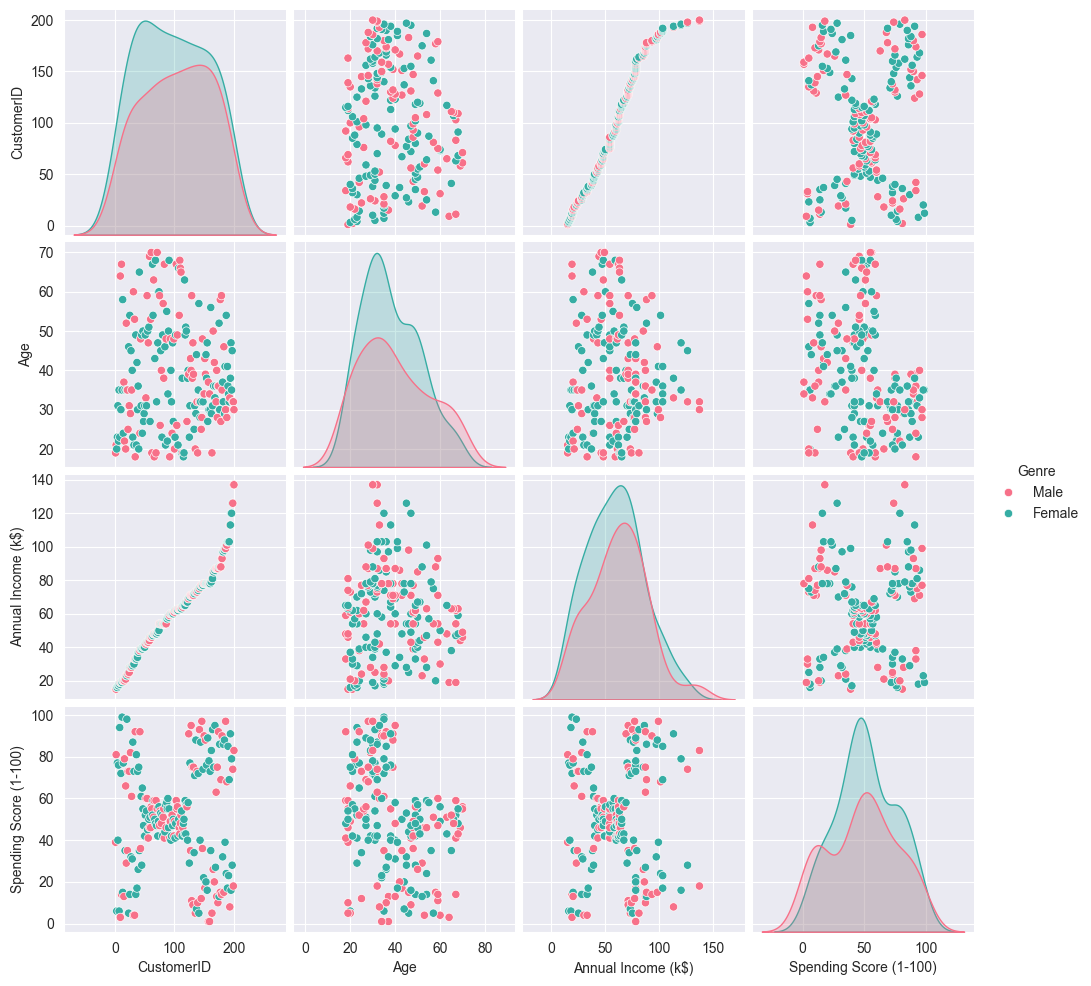

In [18]:
sns.pairplot(
    df,
    hue='Genre',
    palette='husl'
)

plt.show()

In [20]:
# Encode Gender Column

encoder = LabelEncoder()

df['Genre'] = encoder.fit_transform(df['Genre'])

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [21]:
# Selecting Important Features

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [22]:
wcss = []

for i in range(1,11):
    
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)

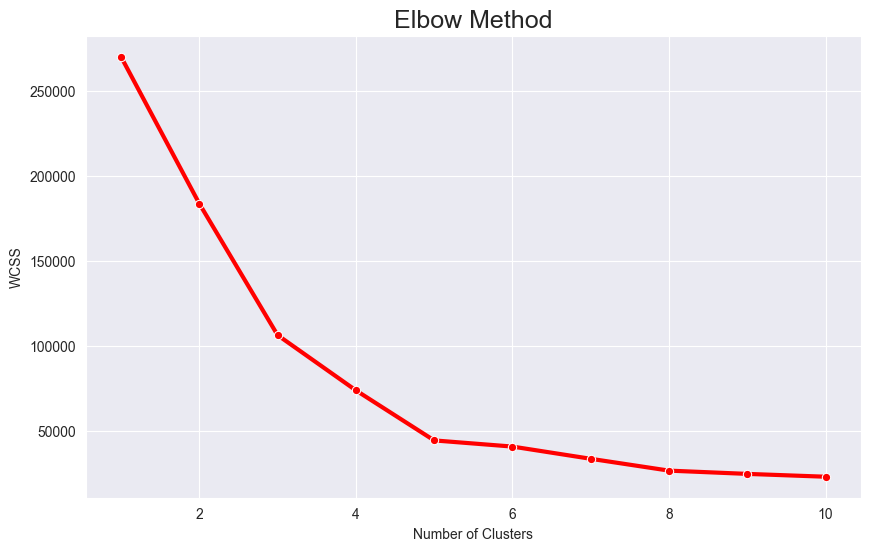

In [23]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=range(1,11),
    y=wcss,
    marker='o',
    linewidth=3,
    color='red'
)

plt.title("Elbow Method", fontsize=18)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [24]:
model = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = model.fit_predict(X)

y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [26]:
# Add Cluster Labels

df['Cluster'] = y_kmeans

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


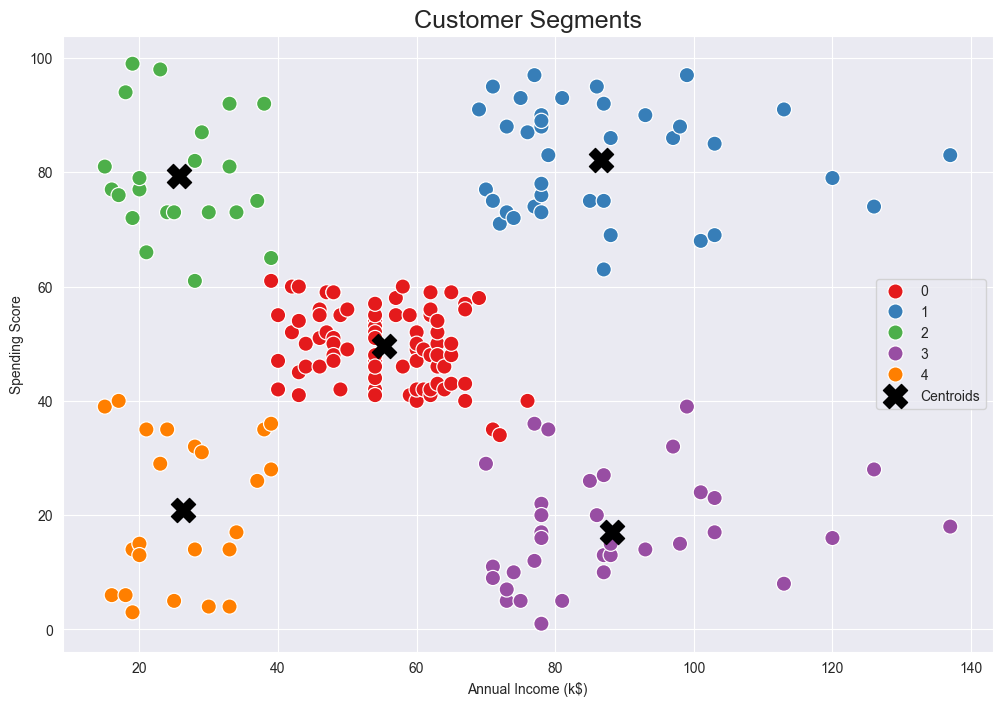

In [27]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x=X.iloc[:,0],
    y=X.iloc[:,1],
    hue=df['Cluster'],
    palette='Set1',
    s=120
)

# Cluster Centers

plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    s=300,
    c='black',
    label='Centroids',
    marker='X'
)

plt.title("Customer Segments", fontsize=18)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.legend()

plt.show()

In [28]:
# Average Values of Each Cluster

cluster_analysis = df.groupby('Cluster').mean()

cluster_analysis

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,86.320988,0.407407,42.716049,55.296296,49.518519
1,162.000000,0.461538,32.692308,86.538462,82.128205
2,23.090909,0.409091,25.272727,25.727273,79.363636
3,164.371429,0.542857,41.114286,88.200000,17.114286
4,23.000000,0.391304,45.217391,26.304348,20.913043


In [29]:
score = silhouette_score(X, y_kmeans)

print("Silhouette Score :", score)

Silhouette Score : 0.553931997444648
